# Week 4 — Plotting, προβλήματα (imbalance, metrics), Μ1 milestone

## Imports & Theme

- Ενιαίο style → όλα τα plots δείχνουν “ίδια” σε report/README.
- save_fig() → ένα call, σταθερή ποιότητα εξόδου.
- Ασφαλές DATA_PATH → λιγότερα “πού είμαι;” προβλήματα στο notebook.
- Colorblind palette → καλύτερη αναγνωσιμότητα.
- context="talk" → μεγαλύτερα fonts που φαίνονται όμορφα σε screenshots/exports.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Reproducibility (seed σε NumPy (π.χ. για sampling/bootstraps αργότερα))----
np.random.seed(42)

# ---- Seaborn / Matplotlib theme ----
sns.set_theme(style="whitegrid", context="talk")  # 'talk' για notebook παρουσιάσεις
sns.set_palette("colorblind")                     # προσβάσιμη παλέτα

# Συγκεντρωμένη αισθητική (rcParams + context): Ενιαίο look (τίτλοι/labels/πλέγμα) και μέγεθος γραμματοσειρών για notebook/αναφορές.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.unicode_minus": False,   # σωστή εμφάνιση του "−"
    "legend.frameon": False,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# ---- Paths ---- 
FIG_DIR = Path("../../reports/figures/week4")
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path("../../data/data_raw/creditcard.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Δεν βρέθηκε το dataset στο {DATA_PATH}. "
        "Έλεγξε το working directory ή προσαρμόσε το PROJECT_ROOT."
    )

# ---- Pandas display  (βοηθά σε preview) ----
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# ---- Helper για αποθήκευση figures ----
def save_fig(name: str, folder: Path = FIG_DIR, ext: str = "png"):
    """
    Αποθηκεύει το τρέχον figure στο FIG_DIR με consistent ρυθμίσεις.
    Χρήση: plt.figure(...); ...plot...; save_fig("heatmap_corr")
    """
    folder.mkdir(parents=True, exist_ok=True)
    out = folder / f"{name}.{ext}"
    plt.savefig(out, bbox_inches="tight")
    print(f"[saved] {out}")

## Load & Basic Info

- Shape + head() → δίνει άμεση εικόνα μεγέθους και περιεχομένου.
- info() & missing values → καλύπτει data quality από την αρχή.
- Class distribution (counts + %) σε DataFrame → ωραία παρουσίαση για report.
- countplot με annotations ποσοστών → άψογο για να δείχνεις το imbalance στο μάτι.

Shape (rows, cols): (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Data Types & Nulls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-n

,Count,Percentage
Class,,
0,284315,99.8273%
1,492,0.1727%


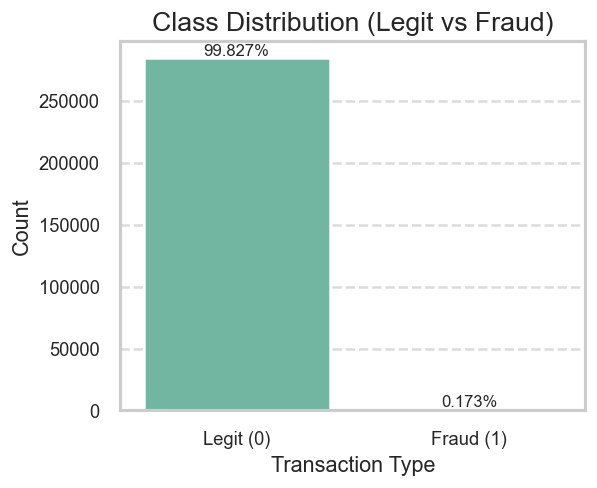

In [4]:
df = pd.read_csv(DATA_PATH)

# Shape του dataset
print(f"Shape (rows, cols): {df.shape}")

# Πρώτες γραμμές
display(df.head())

# Dtypes & Missing values overview
print("\n--- Data Types & Nulls ---")
print(df.info())
print(df.isnull().sum().sum(), "missing values συνολικά")

# Class distribution (counts + percentages)
print("\n--- Class Distribution ---")
class_counts = df["Class"].value_counts().to_frame("Count")
""" df["Class"].value_counts() μετράει πόσες εγγραφές έχεις για Class=0 (legit) και Class=1 (fraud).
    Επιστρέφει Series με index τις τιμές (0,1) και τιμές τα counts.
    .to_frame("Count") το μετατρέπει σε DataFrame με μία στήλη που ονομάζεται Count  """
class_counts["Percentage"] = df["Class"].value_counts(normalize=True).map("{:.4%}".format)
""" normalize=True ζητάει αναλογίες αντί για απόλυτα counts (π.χ. 0.998273 και 0.001727).
    .map("{:.4%}".format) μορφοποιεί αυτές τις αναλογίες ως ποσοστά με 4 δεκαδικά (π.χ. 99.8273%).
    Η νέα στήλη Percentage προστίθεται στο class_counts."""
display(class_counts)

# Γρήγορη οπτικοποίηση class imbalance
plt.figure(figsize=(5,4))
ax = sns.countplot(
    x="Class", data=df, hue="Class",
    palette=["#66c2a5", "#fc8d62"], legend=False
) 
""" Φτιάχνει bar chart των συχνοτήτων της στήλης Class.
    hue="Class": χρησιμοποιείται για να επιτραπεί η χρήση palette ανά κατηγορία (και να αποφύγεις το seaborn 0.14 warning). 
    Επειδή x και hue είναι το ίδιο, θα προκύψει μία μπάρα ανά κατηγορία με το αντίστοιχο χρώμα.
    palette=[...]: χρώματα για Class=0 και Class=1.
    legend=False: κρύβει το legend (δεν χρειάζεται εδώ)."""
ax.set_title("Class Distribution (Legit vs Fraud)")
ax.set_xlabel("Transaction Type")
ax.set_ylabel("Count")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"])
ax.grid(axis="y", linestyle="--", alpha=0.7) # πλέγμα μόνο στον άξονα Υ

# annotations ποσοστών πάνω από τις μπάρες
total = len(df) # σύνολο εγγραφών
for p in ax.patches: 
    percentage = f"{100 * p.get_height() / total:.3f}%" # ποσοστό με 3 δεκαδικά 
    x = p.get_x() + p.get_width() / 2 # κέντρο μπάρας στον άξονα Χ, p.get_x() είναι αριστερό άκρο, p.get_width() το πλάτος / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha="center", va="bottom", fontsize=10)
""" ax.patches είναι οι “μπάρες” (Rectangles).
    Για κάθε μπάρα:
    Υπολογίζει ποσοστό = (ύψος μπάρας / σύνολο εγγραφών) × 100.
    Τοποθετεί το ποσοστό πάνω από τη μπάρα, κεντραρισμένο οριζόντια (ha="center") και ακριβώς επάνω από την κορυφή (va="bottom")."""
plt.show()





## Helper για annotation bars

In [6]:
def annotate_bars(ax, show_count=True, show_pct=True, fontsize=9, color="black"):
    """
    Προσθέτει count & ποσοστά πάνω από bars σε seaborn/matplotlib plot.
    ax: matplotlib.axes.Axes
        To plot axis που περιέχει τις μπάρες.
    show_count, show_pct: bool
        Επιλογή αν θα εμφανιστούν counts / ποσοστά.
    fontsize: int
        Μέγεθος γραμματοσειράς για annotation.
    color: str
        Χρώμα γραμματοσειράς."""
    total = sum([p.get_height() for p in ax.patches])
    if total == 0:
        return ax  # αποφυγή διαίρεσης με μηδέν
    """ Παίρνει τον ax (axes object από matplotlib/seaborn).
        ax.patches είναι όλες οι μπάρες (Rectangle objects).
        get_height() → το ύψος κάθε μπάρας.
        total → συνολικό ύψος όλων των bars (δηλαδή το σύνολο counts αν είναι countplot)."""    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f"{int(height)}\n({height/total:.2%})",
                    (p.get_x()+p.get_width()/2., height),
                    ha="center", va="bottom", fontsize=9)
        """ f"{int(height)}\n({height/total:.2%})" → ετικέτα με:
            τον απόλυτο αριθμό (integer, π.χ. 284315),
            και το ποσοστό (π.χ. (99.83%)) σε νέα γραμμή.
            (p.get_x()+p.get_width()/2., height) → τοποθετεί το κείμενο στο κέντρο της μπάρας (x) και πάνω από την κορυφή (y).
            ha="center", va="bottom" → κέντρο οριζόντια, και “κάτσε πάνω” στη μπάρα.
            fontsize=9 → μικρό και καθαρό μέγεθος."""


## Κατανομή κλάσεων

- δημιουργία → διαμόρφωση → annotation → αποθήκευση → κλείσιμο.
- Το tight_layout() + bbox_inches="tight" εξασφαλίζουν επαγγελματική εμφάνιση στο PNG.
- Xρήση helper function (annotate_bars) για πιο DRY (Don’t Repeat Yourself).

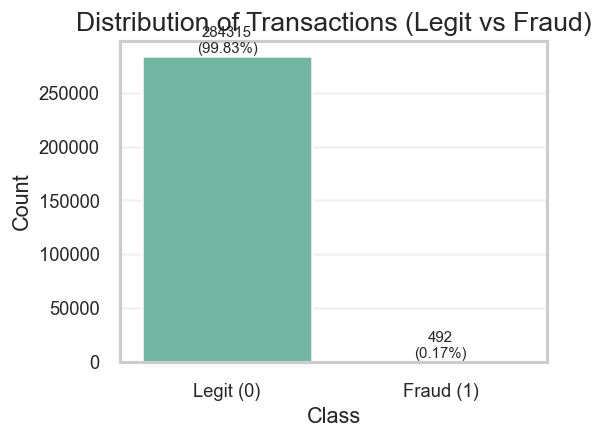

In [7]:
plt.figure(figsize=(5,4))
ax = sns.countplot(
    x="Class", data=df,
    hue="Class", palette=["#66c2a5", "#fc8d62"], legend=False)
ax.set_xticks([0,1])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"])
ax.set_title("Distribution of Transactions (Legit vs Fraud)")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
annotate_bars(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150, bbox_inches="tight", transparent=True) # transparent=True για να μην έχει λευκό background σε αναφορές με σκούρο background
plt.show()
plt.close()


## Ιστόγραμμα Amount (γραμμική κλίμακα)

- (figure → plot → labels → save → close).
- Χρήση bins=50 (αρκετά “λεπτομερές” χωρίς να γίνεται πολύ noisy).
- Αποθήκευση με dpi=150 + bbox_inches="tight"

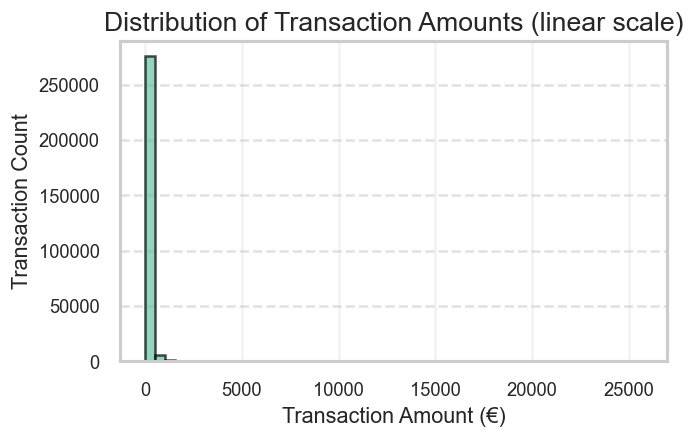

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df["Amount"], bins=50, color="#66c2a5", edgecolor="black", alpha=0.7)
""" Χτίζει ιστόγραμμα της στήλης Amount (ποσό συναλλαγής).
    bins=50 → χωρίζει τα ποσά σε 50 κουτιά/intervals.
    Ο άξονας x = ποσά, ο άξονας y = συχνότητες."""
plt.title("Distribution of Transaction Amounts (linear scale)")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Transaction Count")
plt.grid(axis="y", linestyle="--", alpha=0.6) # Προσθήκη grid για ευκολότερη ανάγνωση
plt.tight_layout() # διάταξη ώστε να μη “κόβονται” labels
plt.savefig(FIG_DIR / "amount_hist.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


## Ιστόγραμμα Amount (λογαριθμική κλίμακα Y)

- Χρησιμοποιώ log-scale στο Y → πολύ κρίσιμο για skewed data όπως οι συναλλαγές.
(Skewed data is asymmetrical data that does not follow a normal, bell-shaped distribution, creating a long "tail" on one side of the graph)
- Περισσότερα bins (100) → δείχνει λεπτομέρειες στην κατανομή.
- Αποθήκευση με tight_layout + bbox_inches="tight" → καθαρή εικόνα

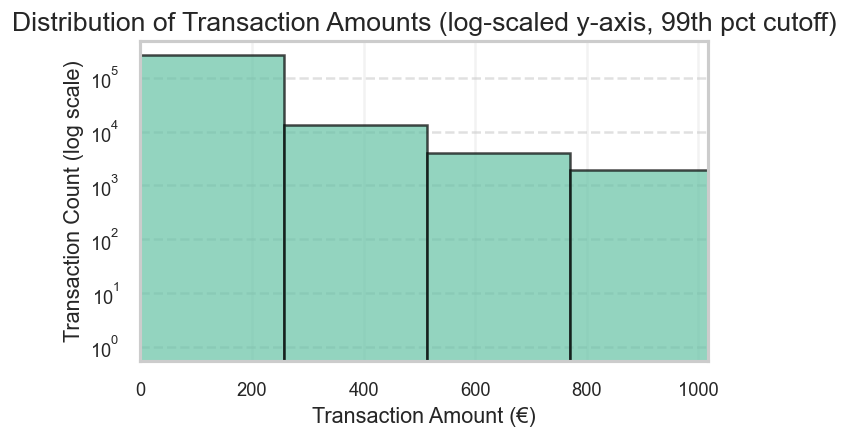

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df["Amount"], bins=100, color="#66c2a5", edgecolor="black", alpha=0.7)
# Ιστόγραμμα της στήλης Amount, αυτή τη φορά με 100 bins (πιο λεπτομερές απ’ ότι πριν με 50)
plt.yscale("log")  # για καλύτερη ανάγνωση της ουράς
""" Ο y-άξονας (counts) γίνεται λογαριθμικός.
    Έτσι φαίνονται καθαρά και οι σπάνιες συναλλαγές με πολύ μεγάλα ποσά 
    (που αλλιώς “εξαφανίζονται” στο γράφημα)"""
plt.xlim(0, df["Amount"].quantile(0.99))  # cutoff στο 99th percentile
# Τα πολύ μεγάλα amounts (π.χ. >5000 €) τραβάνε τον άξονα. Με cutoff στο 99th percentile η πλοκή γίνεται πιο “business-ready”:
plt.title("Distribution of Transaction Amounts (log-scaled y-axis, 99th pct cutoff)")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Transaction Count (log scale)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "amount_hist_log.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


## Ιστόγραμμα Time

- (create → plot → labels → save → close).
- Χρησιμοποιώ descriptive xlabel γιατί το “Time” μόνο του είναι ασαφές.
- Αποθηκεύω με dpi=150 για καλή ποιότητα.

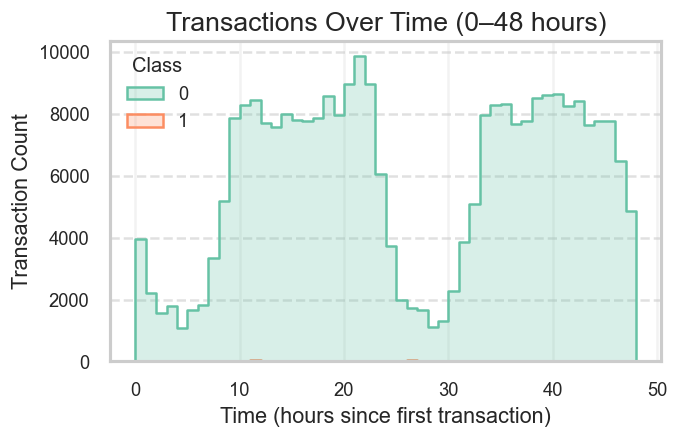

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x=df["Time"]/3600, bins=48, hue="Class",
             element="step", stat="count", common_norm=False,
             palette={0:"#66c2a5", 1:"#fc8d62"})
""" data=df
    Λέει στο seaborn να πάρει τα δεδομένα από το DataFrame df.
x=df["Time"]/3600
    Ορίζουμε τον άξονα Χ.
    Εδώ παίρνουμε τη στήλη Time (που είναι σε δευτερόλεπτα) και τη μετατρέπουμε σε ώρες (/3600).
    Έτσι, το ιστόγραμμα δείχνει την κατανομή συναλλαγών μέσα σε ~48 ώρες.
bins=48
    Χωρίζει τα δεδομένα σε 48 κουτάκια (bins).
    Επειδή το dataset καλύπτει περίπου 48 ώρες, σημαίνει ότι κάθε bin ≈ 1 ώρα.
hue="Class"
    Χρωματίζει διαφορετικά τις μπάρες ανάλογα με το αν η συναλλαγή είναι Legit (Class=0) ή Fraud (Class=1).
    Δηλαδή έχουμε overlay/διαχωρισμό κατανομής ανά κατηγορία.
element="step"
    Αντί να γεμίσει τις μπάρες, φτιάχνει "outline" (σαν γραμμή που ακολουθεί το σχήμα του histogram).
    Έτσι φαίνεται καθαρά το overlap των δύο κατηγοριών.
stat="count"
    Ο άξονας Υ δείχνει απόλυτο πλήθος συναλλαγών ανά bin (όχι density/ποσοστά).
common_norm=False
    Χωρίζει τις κατηγορίες (Legit/Fraud) και δεν τις κανονικοποιεί μαζί.
    Έτσι βλέπεις τα πραγματικά counts για κάθε Class.
    Αν ήταν True, θα έκαναν normalize όλα μαζί (θα ήταν λιγότερο ξεκάθαρο λόγω imbalance).
palette={0:"#66c2a5", 1:"#fc8d62"}
    Ορίζει custom χρώματα για το hue:
        Class=0 (Legit) → πράσινο-μπλε #66c2a5
        Class=1 (Fraud) → πορτοκαλί #fc8d62"""
plt.title("Transactions Over Time (0–48 hours)")
plt.xlabel("Time (hours since first transaction)")
plt.ylabel("Transaction Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "time_hist.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


## Κατανομή Amount ανά Class (overlay)

- quantile(0.99) → καθαρό γράφημα χωρίς να εξαφανίζονται τα “μικρά” amounts.
- Χρησιμοποιώ density για να συγκρίνω σχήματα κατανομών, όχι raw counts (έχω imbalanced data).
- Overlay με element="step" → καθαρή εικόνα, φαίνεται η διαφορά μεταξύ classes.

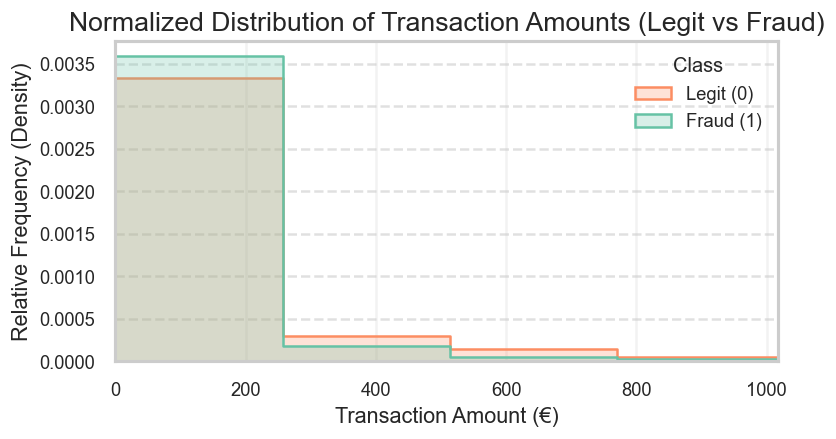

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="Amount", hue="Class", bins=100, element="step", 
             stat="density", common_norm=False, palette={0: "#66c2a5", 1: "#fc8d62"})
""" x="Amount" → οριζόντιος άξονας = ποσό συναλλαγής.
    hue="Class" → χρωματίζει ξεχωριστά Legit (0) vs Fraud (1).
    bins=100 → περισσότερη λεπτομέρεια.
    element="step" → φτιάχνει διαφανή γραμμές αντί για “γεμάτες” μπάρες (ώστε να βλέπεις τα overlays).
    stat="density" → κανονικοποιεί τα ύψη ώστε κάθε κατηγορία να έχει άθροισμα = 1 (δείχνει σχετικές συχνότητες).
    common_norm=False → κάθε κατηγορία κανονικοποιείται ξεχωριστά, για να συγκρίνονται τα σχήματα (όχι τα μεγέθη)."""
plt.xlim(0, df["Amount"].quantile(0.99))  # Περιορίζει τον x-axis μέχρι το 99ο percentile → κόβει τα outliers (τεράστιες συναλλαγές) που χαλάνε το scale
plt.title("Normalized Distribution of Transaction Amounts (Legit vs Fraud)")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Relative Frequency (Density)")
plt.legend(title="Class", labels=["Legit (0)", "Fraud (1)"])
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "amount_by_class_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


## Boxplot Amount ανά Class (με outliers)

- boxplot → καλό για σύγκριση κατανομών ανά Class.
- Αποθήκευση με dpi=150 → καθαρό για report.

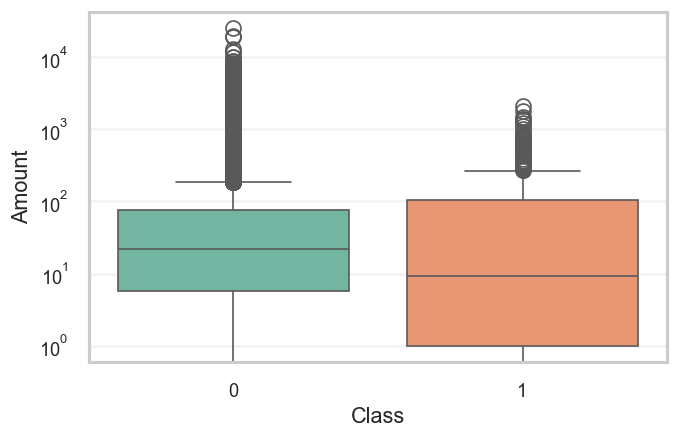

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Class", y="Amount", hue="Class", palette={0: "#66c2a5", 1: "#fc8d62"}, legend=False)
""" Φτιάχνει boxplot με seaborn:
    x="Class" → στον x-axis οι κατηγορίες (0 = legit, 1 = fraud).
    y="Amount" → στον y-axis τα ποσά συναλλαγών.
    Το boxplot δείχνει median, quartiles, whiskers και outliers.
    Επειδή τα amounts έχουν πολύ μεγάλη ουρά, θα εμφανιστούν πολλά outliers"""
plt.yscale("log") # Για να φαίνεται καλύτερα το spread
ax.set_title("Distribution of Transaction Amounts (Legit vs Fraud)")
ax.set_xlabel("Class")
ax.set_ylabel("Amount (€) [log scale]")
ax.set_xticklabels(["Legit (0)", "Fraud (1)"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{int(y):,}"))
"""ax.yaxis
→ παίρνουμε τον άξονα Υ από το subplot (τον ax).
set_major_formatter(...)
→ ορίζει πώς θα εμφανίζονται τα labels στα “major ticks” του άξονα Υ.
(δηλαδή τα βασικά σημάδια/τιμές που γράφει ο άξονας).
plt.FuncFormatter(...)
→ είναι ένας formatter που σου επιτρέπει να δώσεις συνάρτηση για να ορίσεις το format του κάθε label.
lambda y, _: f"{int(y):,}"
    y είναι η αριθμητική τιμή του tick (π.χ. 1000, 10000, 250000).
    _ είναι το “θέση” του tick (δεν το χρειαζόμαστε εδώ, γι’ αυτό το γράφουμε _).
    int(y) μετατρέπει την τιμή σε ακέραιο.
    f"{int(y):,}" → μορφοποιεί τον αριθμό με χιλιάδες διαχωριστικό (,).
        π.χ. 1000 → 1,000, 2500000 → 2,500,000."""
plt.tight_layout()
plt.savefig(FIG_DIR / "amount_by_class_box_log.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


## Heatmap συσχέτισης για ΟΛΕΣ τις αριθμητικές στήλες

- select_dtypes("number"): πιάνει μόνο αριθμητικές στήλες (άρα δεν σπάει αν προστεθούν κείμενα μελλοντικά).
- corr(method="pearson"): για συνεχείς μεταβλητές και binary στόχο (Class) δίνει point-biserial.
(Η συσχέτιση point-biserial είναι μια στατιστική μέτρηση που ποσοτικοποιεί τη δύναμη και την κατεύθυνση της σχέσης μεταξύ μιας συνεχούς μεταβλητής και μιας διχοτομικής (δυαδικής) μεταβλητής, όπως για παράδειγμα η επίδοση σε ένα τεστ (συνεχής) και αν μια ερώτηση απαντήθηκε σωστά ή λάθος (διχοτομική). Είναι μια ειδική περίπτωση της συσχέτισης Pearson*, με συντελεστή που κυμαίνεται από -1 έως +1, όπου το 1 υποδηλώνει τέλεια θετική συσχέτιση, το -1 τέλεια αρνητική συσχέτιση και το 0 καθόλου συσχέτιση.
*Ο συντελεστής συσχέτισης Pearson, ή r του Pearson, ποσοτικοποιεί την ισχύ και την κατεύθυνση μιας γραμμικής σχέσης μεταξύ δύο συνεχών μεταβλητών. Κυμαίνεται από -1 έως 1, ο συντελεστής αυτός δείχνει πόσο στενά ευθυγραμμίζονται τα σημεία δεδομένων σε ένα διάγραμμα διασποράς με μια ευθεία γραμμή.)
- vmin/vmax/center: ίδια χρωματική κλίμακα σε όλα τα heatmaps → συγκρίσιμα γραφήματα.
- square=True, linewidths=.3: δίνει «business» εμφάνιση, καθαρά χωρισμένα κελιά.
- cbar_kws: με label ώστε να ξέρει ο αναγνώστης τι βλέπει.

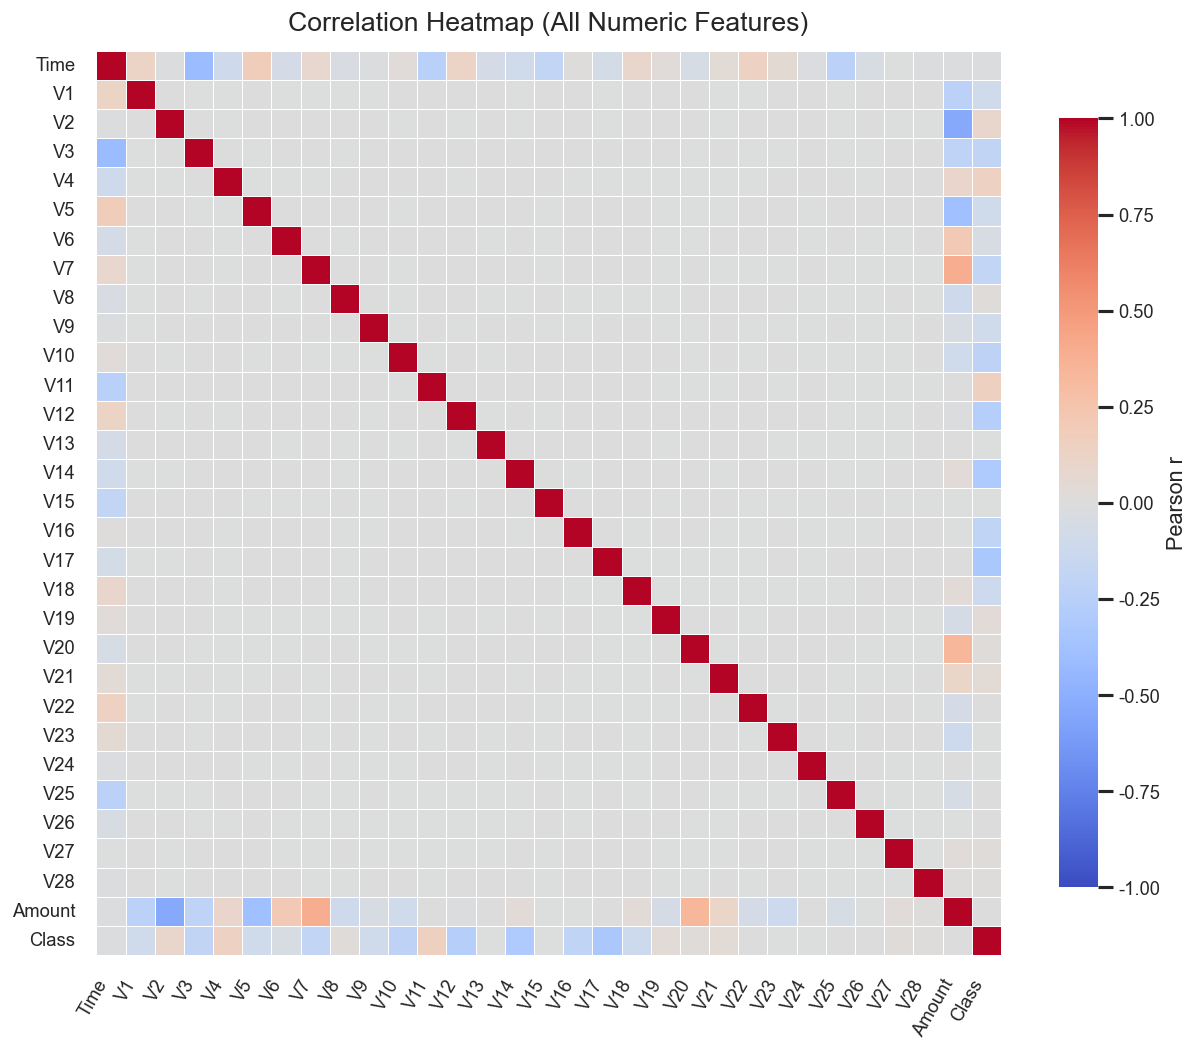

In [14]:
# --- Correlation (all numeric) -----------------------------------------------
num_df = df.select_dtypes(include="number")             # ασφαλές σε pandas >=1.x
corr_all = num_df.corr(method="pearson")                # point-biserial για Class (ουσιαστικά Pearson)

plt.figure(figsize=(11, 9))
ax = sns.heatmap(
    corr_all,
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,                       # συνεπής κλίμακα [-1, 1]
    square=True,                                     # τετράγωνο πλέγμα
    linewidths=.3, linecolor="white",                # λεπτές γραμμές για καθαρότητα
    cbar_kws={"shrink": .85, "label": "Pearson r"}   # μικρότερο colorbar, label
)
ax.set_title("Correlation Heatmap (All Numeric Features)", pad=12, fontsize=16)
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_heatmap_full.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


📊 Δείχνει τις συσχετίσεις όλων των numeric μεταβλητών (Time, V1–V28, Amount, Class).
 
- Τι παρατηρούμε:
    - Σχεδόν όλα τα στοιχεία V1–V28 έχουν πολύ χαμηλές συσχετίσεις μεταξύ τους (αναμενόμενο, γιατί προέρχονται από PCA).
    - Ελάχιστες μεταβλητές έχουν ασθενείς συσχετίσεις με το target Class (αδύναμα χρώματα στην τελευταία στήλη).

- Business insight:
Καμία "κλασική" μεταβλητή (π.χ. Amount, Time) δεν έχει ισχυρή γραμμική σχέση με τη μεταβλητή απάτης → χρειάζεται ML για να μάθει μη γραμμικά patterns.

## Heatmap μόνο για Time, V1–V28, Amount, Class (με τριγωνική μάσκα)

📝 Σημείωση: Τα V1–V28 είναι PCA components (από ανωνυμοποίηση). Οι PCA άξονες είναι ορθογώνιοι/ασυσχέτιστοι στον χώρο που προέκυψαν — μην ερμηνεύσεις τις μεταξύ τους συσχετίσεις σαν «αιτιακές».
- Μάσκα τριγώνου: αποφεύγεις διπλή πληροφορία (πάνω/κάτω τρίγωνο) και μειώνεις το «οπτικό θόρυβο».
- Ίδια κλίμακα με το πρώτο heatmap για συνέπεια.

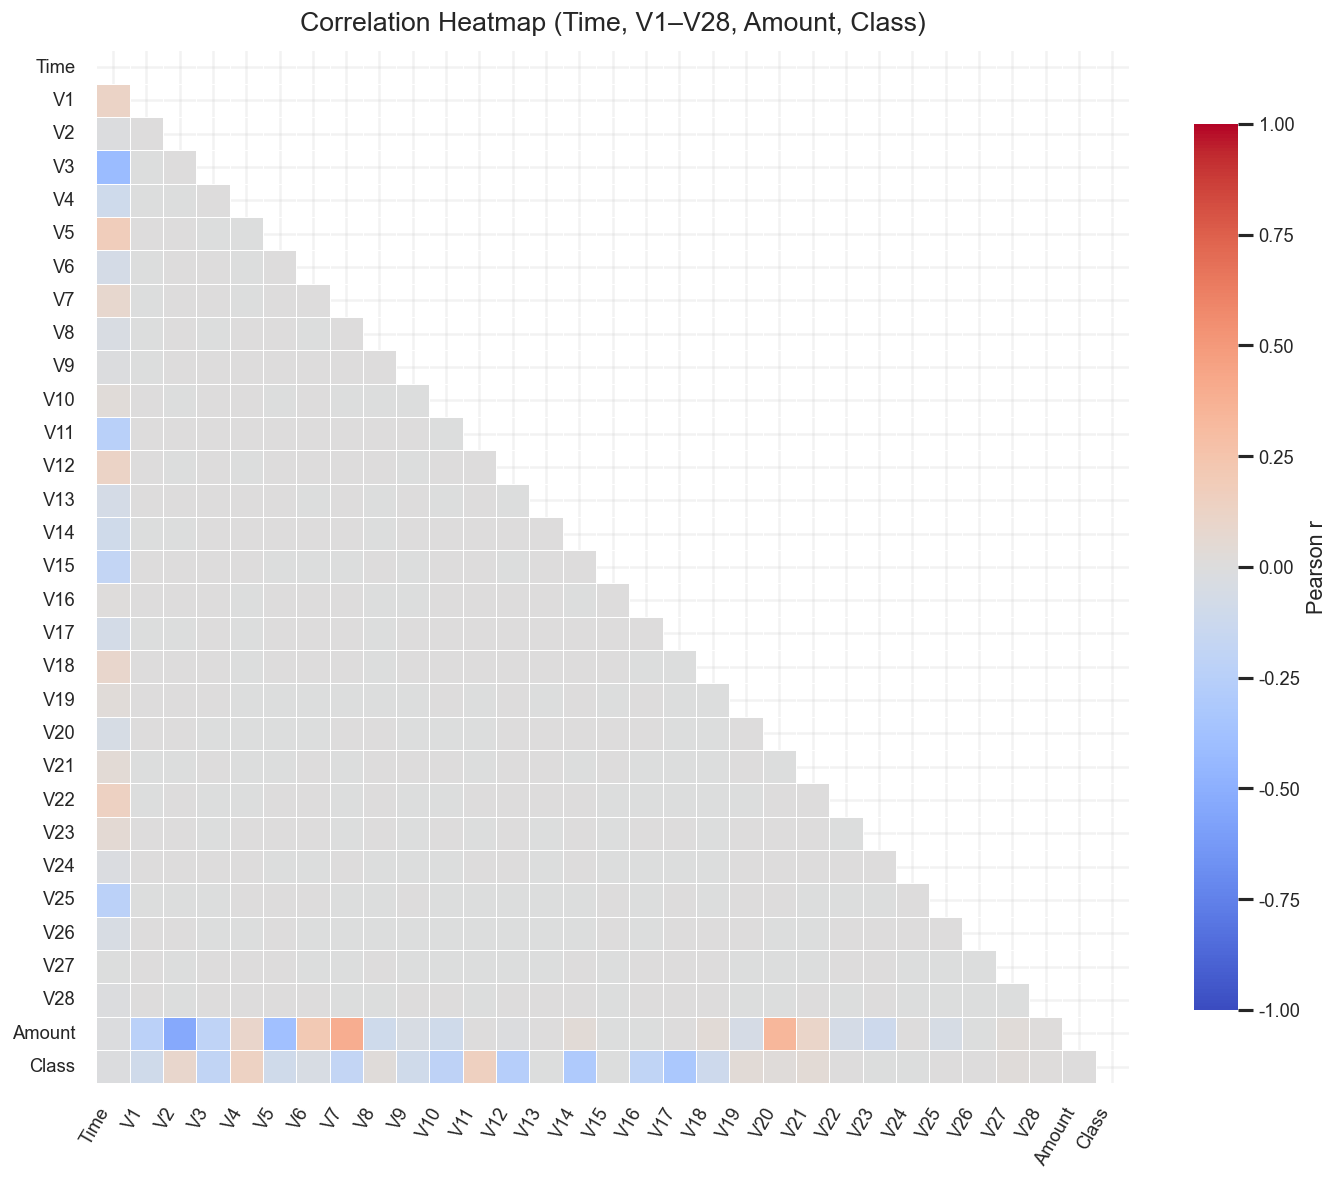

In [16]:
# --- Sub-correlation: Time, V1–V28, Amount, Class ---------------------------
pca_cols = [c for c in df.columns if c.startswith("V") and c[1:].isdigit()]
cols     = ["Time"] + pca_cols + ["Amount", "Class"]
sub      = df[cols].copy()

corr_sub = sub.corr(method="pearson")
mask     = np.triu(np.ones_like(corr_sub, dtype=bool))  # κρατάμε το κάτω τρίγωνο

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr_sub, mask=mask,
    cmap="coolwarm", vmin=-1, vmax=1, center=0,
    square=True, linewidths=.3, linecolor="white",
    cbar_kws={"shrink": .85, "label": "Pearson r"}
)
ax.set_title("Correlation Heatmap (Time, V1–V28, Amount, Class)", pad=12, fontsize=16)
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_heatmap_pca_masked.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


📊 Επικεντρώνεται μόνο σε βασικά πεδία: χρόνο, PCA components, ποσό και Class. Χρησιμοποιεί μάσκα τριγώνου για καθαρότερη παρουσίαση.

- Τι παρατηρούμε:
    - Η εικόνα είναι πολύ καθαρότερη (δεν επαναλαμβάνονται συμμετρικά οι ίδιες συσχετίσεις).
    - Τα ίδια συμπεράσματα ισχύουν: λίγες μεταβλητές έχουν αξιοσημείωτη, αν και μικρή, συσχέτιση με Class.
- Business insight:
Σαν visualization είναι πιο "executive-ready" γιατί τονίζει μόνο τις χρήσιμες συσχετίσεις (πάνω από το τρίγωνο δεν έχει περιττές πληροφορίες).

## Barplot: συσχέτιση κάθε feature με το Class

Δίνει άμεσο μήνυμα σε business κοινό: ποια features σχετίζονται περισσότερο με το fraud (κατά απόλυτη τιμή).

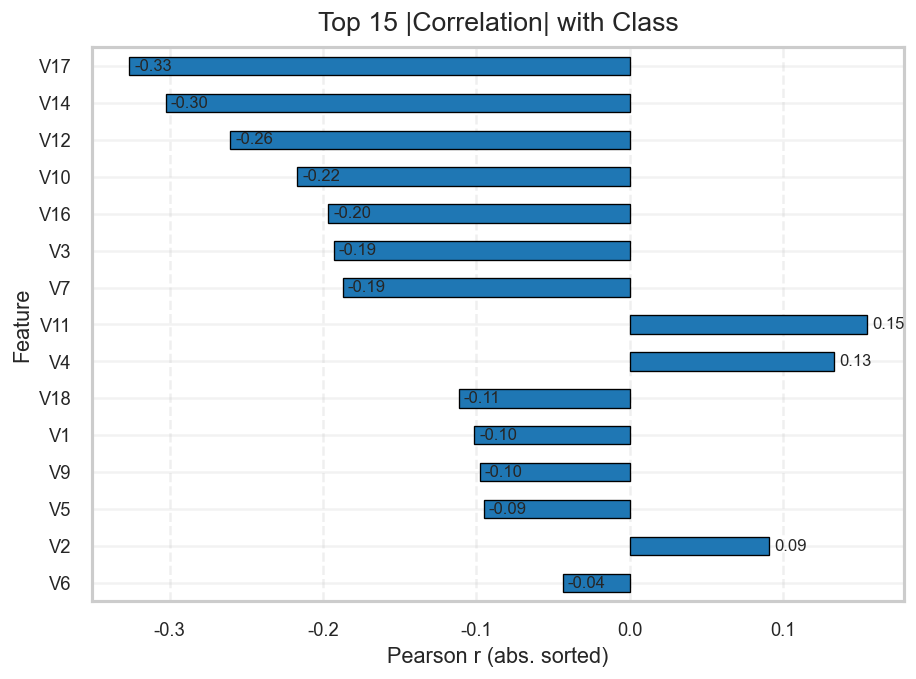

In [17]:
# --- Correlation with target Class (barplot) --------------------------------
corr_with_target = (
    df.select_dtypes("number").corr(method="pearson")["Class"]
    .drop("Class")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_n = 15
plt.figure(figsize=(8, 6))
ax = corr_with_target.head(top_n)[::-1].plot(kind="barh", color="#1f77b4", edgecolor="black", linewidth=0.8)
ax.set_title(f"Top {top_n} |Correlation| with Class", pad=10, fontsize=16)
ax.set_xlabel("Pearson r (abs. sorted)")
ax.set_ylabel("Feature")
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}", (p.get_x()+p.get_width(), p.get_y()+p.get_height()/2),
                va="center", ha="left", fontsize=10, xytext=(3,0), textcoords="offset points")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_with_class_top.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


📊 Bar chart που δείχνει τις ισχυρότερες (σε απόλυτη τιμή) συσχετίσεις με το Class.

- Τι παρατηρούμε:
    - Το V17 (ρ ≈ −0.33), V14 (ρ ≈ −0.30) και V12 (ρ ≈ −0.26) είναι τα πιο σχετικά με το target.
    - Ακόμη και οι πιο "ισχυρές" συσχετίσεις είναι μέτριες, όχι ισχυρές (>0.5).
- Business insight:
Δεν υπάρχει κάποιο χαρακτηριστικό που από μόνο του να ξεχωρίζει τους fraud vs legit — είναι συνδυασμοί χαρακτηριστικών που έχουν σημασία. Αυτό εξηγεί γιατί απλοί κανόνες (π.χ. thresholds) δεν επαρκούν και χρειαζόμαστε supervised ML.

## Clustermap για ομαδοποίηση χαρακτηριστικών

Όταν έχεις πολλά features, η ιεραρχική ομαδοποίηση τα ομαδοποιεί οπτικά.

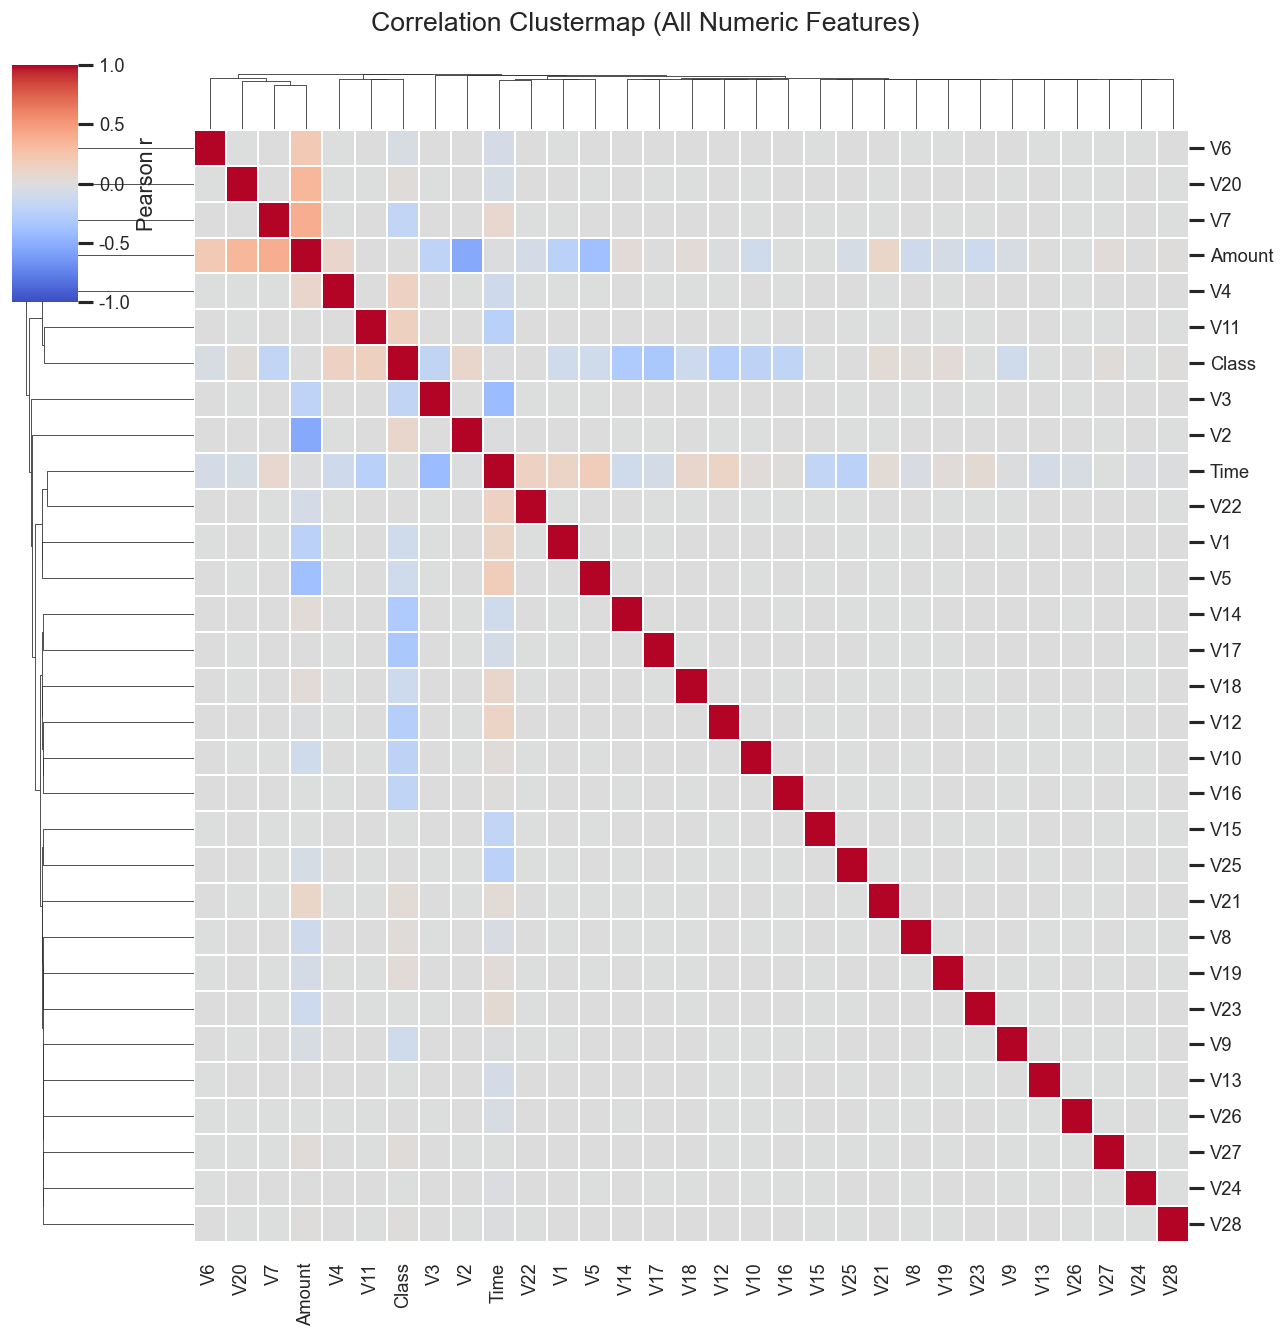

In [18]:
# --- Optional: Clustermap (hierarchical) ------------------------------------
g = sns.clustermap(
    corr_all, cmap="coolwarm", vmin=-1, vmax=1, center=0,
    figsize=(11, 11), linewidths=.2, dendrogram_ratio=(.15, .05),
    cbar_kws={"shrink": .8, "label": "Pearson r"}
)
g.fig.suptitle("Correlation Clustermap (All Numeric Features)", y=1.02, fontsize=16)
g.savefig(FIG_DIR / "corr_clustermap_full.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

📊 Heatmap με ιεραρχικό clustering (dendrograms) για να ομαδοποιεί features με παρόμοια patterns συσχέτισης.

- Τι παρατηρούμε:
    - Ομαδοποιεί κάποιες μεταβλητές (π.χ. V14, V17, V12, V10, V16 πάνε κοντά, γιατί σχετίζονται μεταξύ τους και με το Class).
    - Αυτό είναι ιδιαίτερα χρήσιμο για feature selection ή dimensionality reduction, ώστε να ξέρουμε ποια features "κουβαλούν" παρόμοια πληροφορία.
- Business insight:
Οπτικά μπορείς να δείξεις σε ένα manager ότι "υπάρχουν clusters μεταβλητών που συμπεριφέρονται παρόμοια" → βοηθά να δικαιολογήσεις PCA/feature engineering στο pipeline.

- Pearson vs Spearman: Αν υποψιάζεσαι μη-γραμμικές/μονότονες σχέσεις (π.χ. Amount με heavy tails), δοκίμασε method="spearman" και σύγκρινε.
- Target Class (binary): Ο Pearson εδώ ισοδυναμεί με point-biserial συσχέτιση, χρήσιμο quick-screening. Δεν αντικαθιστά την μοντελοποίηση.
- PCA components (V1–V28): είναι συνδυασμοί αρχικών μεταβλητών — οι μεταξύ τους συσχετίσεις δεν ερμηνεύονται σαν «feature A σχετίζεται αιτιακά με feature B».
- Business takeaway: Χρησιμοποίησε το “Top |Correlation| with Class” για να δώσεις λιστούλα με VIP features στη συζήτηση με stakeholders.